# Bank Customer Churn Prediction 

Objective: Identify customers who are likely to leave the bank.

In [1]:
#Import the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
#Load the dataset
df= pd.read_csv('Churn_Modelling.csv')

#### Understanding the dataset

In [3]:
df.shape              # rows.columns

(10000, 14)

In [5]:
df.dtypes             # datatype of columns 

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Some columns need to be dropped such as RowNumber,CustomerId, Surname as they have no predictive value, while gender & geography will be encoded.

In [6]:
print(df['Exited'].value_counts(normalize=True))    # check class imbalance

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


We have a ~80/20 class imbalance. If we leave it be, our model can reach 79.6% accuracy by just predicting "Stayed" for everyone.

To solve this class imbalance we will use (The class_weight='balanced') in Random Forest to automatically adjust it. 

In [7]:
#Check for missing values
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
#Clean & prepare the data

#Dropping columns with no predictive value
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [9]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


The dataset contains 10,000 customer records with no missing numerical values. Customers have an average credit score of 650, average age of 39 years, and average tenure of 5 years, showing a mix of new and long-term customers. Around 70% own a credit card and 51% are active members. The churn rate is 20.4%, indicating class imbalance with most customers staying. Balance and salary show high variation, suggesting customer financial status differs significantly across the dataset.

#### Visualization

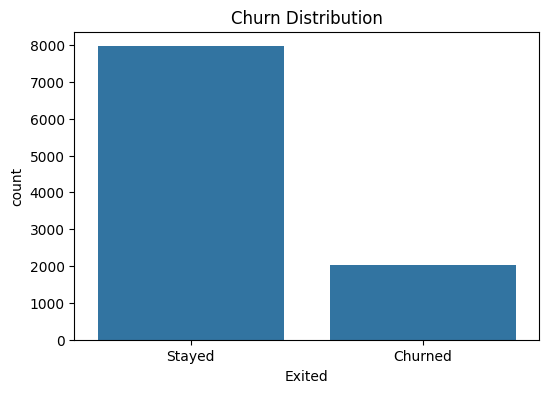

In [11]:
import seaborn as sns
# 5. Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.xticks([0,1], ['Stayed','Churned'])
plt.show()

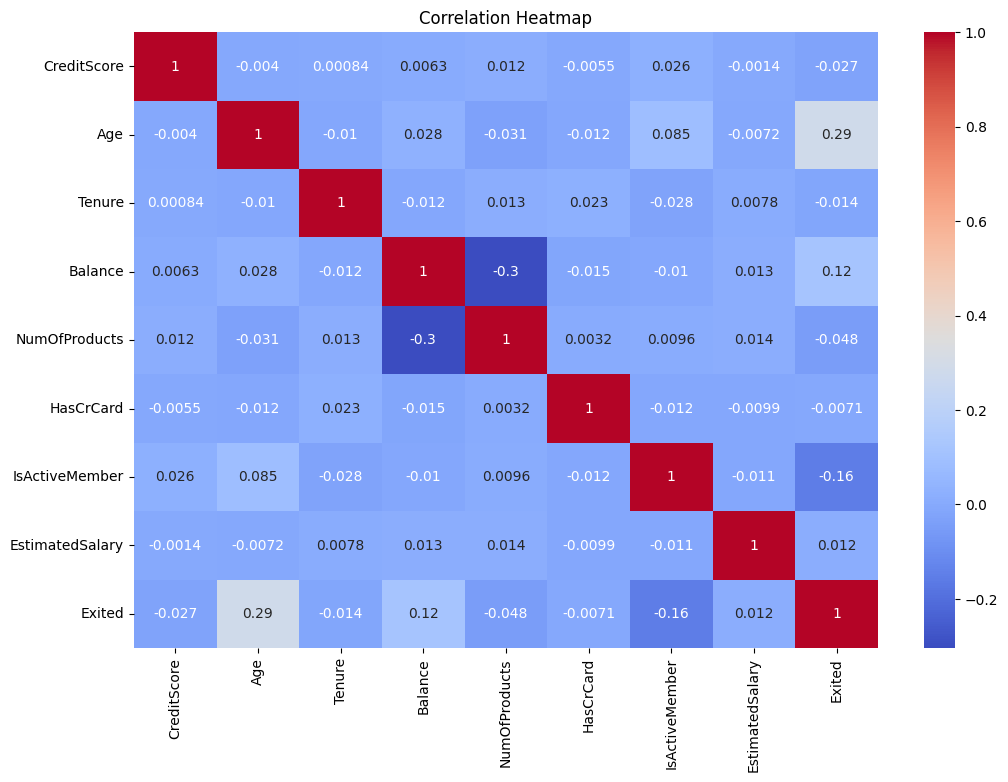

In [13]:
# 7. Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Categorical Analysis

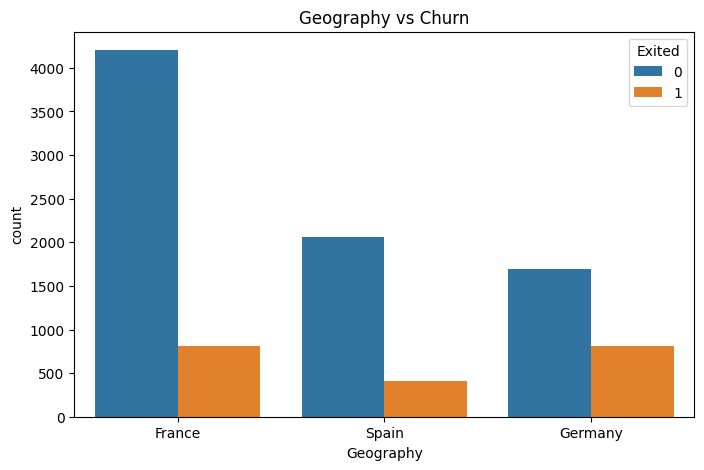

In [14]:
# Geography vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title("Geography vs Churn")
plt.show()

France and Spain have similar customer bases and nearly identical churn rates. Germany is dramatically different — it has fewer total customers than France but almost the same number of churners, pushing its churn rate to roughly double that of the other two countries.
<br>
The bank should investigate whether it's a pricing issue, service quality, local competition, or product-market fit specific to German customers and invest in targeted retention strategies  .

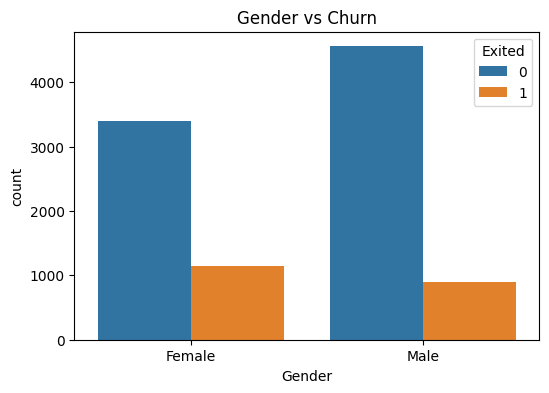

In [15]:
# Gender vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title("Gender vs Churn")
plt.show()

There are more Male customers than Female, but the female churn rate is higher than that of males, Bank should look for strategies to retain their female customers

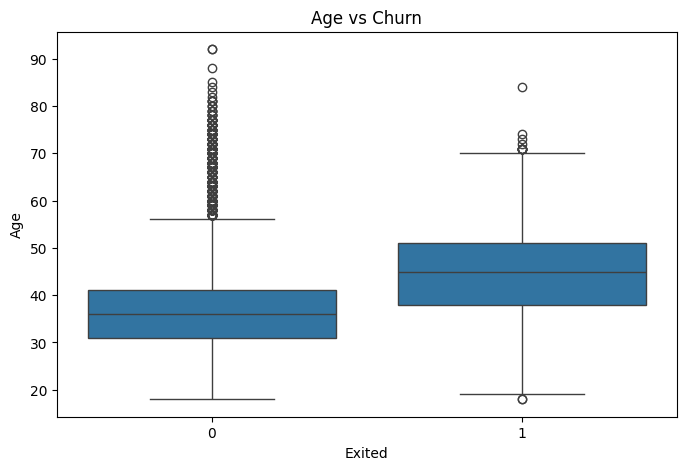

In [16]:
# Age impact
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age vs Churn")
plt.show()

### Encode categorical features

In [18]:
# Label Encoding for binary Gender column
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Female=0, Male=1

In [19]:
# One-Hot Encoding for Geography (3 categories)
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [20]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [21]:
#Split the dataset
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify preserves class ratio
)

# Scale numeric features (important for distance-based models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)                   # fit only on train to prevent data leakage

###  Train the classifier

In [22]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # handles the ~80/20 class imbalance
    random_state=42
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

###  Evaluate

In [23]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000



The model performs excellently at identifying customers who will stay, achieving a precision of 0.87, recall of 0.97. This means nearly all customers predicted to stay do in fact stay, and very few actual non-churners are missed.
<br>
Performance on the minority class(Class 1)is moderate. The model achieves a precision of 0.79, meaning that when it flags a customer as likely to churn, it is correct 79% of the time. However, recall stands at only 0.44 — the model misses 56% of actual churners. 

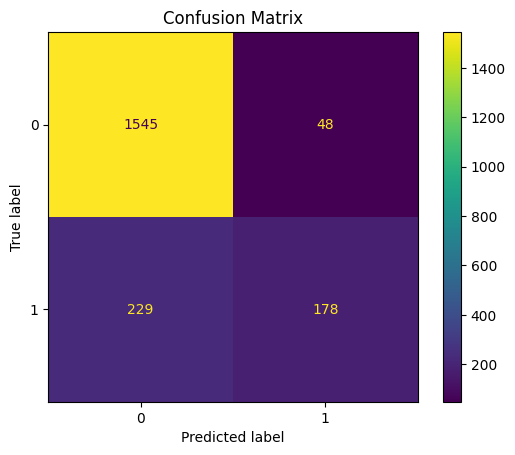

In [25]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix')
plt.show()

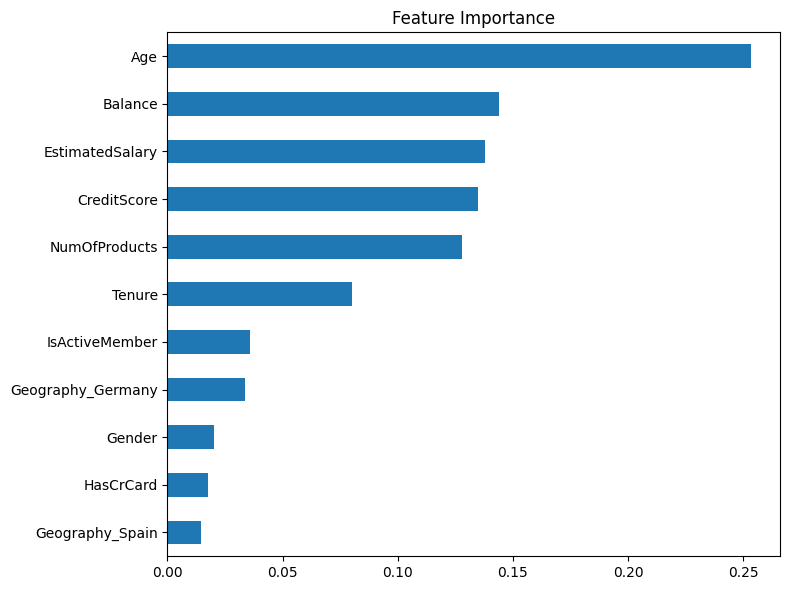

In [26]:
# Feature importance bar chart
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6), title='Feature Importance')
plt.tight_layout()
plt.show()

### Conclusion:

Feature importance analysis from the Random Forest model reveals that Age is the single strongest predictor of churn, followed by Balance, EstimatedSalary, CreditScore, and NumOfProducts. Behavioral indicators such as IsActiveMember and geographic signals like Geography_Germany contribute meaningfully but at a lower magnitude. Gender carries the least predictive power. These findings suggest that churn is primarily driven by customer life stage and financial profile rather than engagement behavior alone, and that retention strategies should prioritize middle-aged, high-balance customers with limited product holdings.